In [1]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd

In [6]:
data2 = pd.read_csv('hour.csv')

In [7]:
data2.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.3 MB


In [8]:
X = data2.drop(columns=['dteday', 'instant', 'cnt']).values
y = data2['cnt'].values

scaler_y = StandardScaler()
y = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

scaler2 = StandardScaler()
X_train_scaled = scaler2.fit_transform(X_train)
X_test_scaled = scaler2.transform(X_test)

In [9]:
X_tr = torch.FloatTensor(X_train_scaled)
y_tr = torch.FloatTensor(y_train).reshape(-1, 1)
X_te = torch.FloatTensor(X_test_scaled)
y_te = torch.FloatTensor(y_test)

In [10]:
batch_size = 256
train_dataset = torch.utils.data.TensorDataset(X_tr, y_tr)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=batch_size,
                                           shuffle=True)

In [11]:
class NeuralNet2(nn.Module):
    def __init__(self, input_size=14, hidden_size=56, num_classes=1):
        super(NeuralNet2, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

model = NeuralNet2()

num_epochs = 50
learning_rate = 0.01

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [12]:
total_step = len(train_loader)
loss_history = []
for epoch in range(num_epochs):
    epoch_loss = 0
    for i, (features, labels) in enumerate(train_loader):

        outputs = model(features)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)

    print('Epoch [{}/{}], Loss: {:.4f}'.format(epoch+1, num_epochs, avg_loss))

model.eval()
with torch.no_grad():
    pred_scaled = model(X_te)

    pred_numpy = pred_scaled.numpy().reshape(-1, 1)
    y_te_numpy = y_te.numpy().reshape(-1, 1)

    pred_original = scaler_y.inverse_transform(pred_numpy)
    y_test_original = scaler_y.inverse_transform(y_te_numpy)

    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    mae = mean_absolute_error(y_test_original, pred_original)
    mse = mean_squared_error(y_test_original, pred_original)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_original, pred_original)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

Epoch [1/50], Loss: 0.1238
Epoch [2/50], Loss: 0.0026
Epoch [3/50], Loss: 0.0014
Epoch [4/50], Loss: 0.0010
Epoch [5/50], Loss: 0.0007
Epoch [6/50], Loss: 0.0006
Epoch [7/50], Loss: 0.0004
Epoch [8/50], Loss: 0.0004
Epoch [9/50], Loss: 0.0003
Epoch [10/50], Loss: 0.0003
Epoch [11/50], Loss: 0.0002
Epoch [12/50], Loss: 0.0002
Epoch [13/50], Loss: 0.0002
Epoch [14/50], Loss: 0.0001
Epoch [15/50], Loss: 0.0001
Epoch [16/50], Loss: 0.0001
Epoch [17/50], Loss: 0.0001
Epoch [18/50], Loss: 0.0001
Epoch [19/50], Loss: 0.0001
Epoch [20/50], Loss: 0.0001
Epoch [21/50], Loss: 0.0001
Epoch [22/50], Loss: 0.0001
Epoch [23/50], Loss: 0.0001
Epoch [24/50], Loss: 0.0001
Epoch [25/50], Loss: 0.0000
Epoch [26/50], Loss: 0.0000
Epoch [27/50], Loss: 0.0000
Epoch [28/50], Loss: 0.0000
Epoch [29/50], Loss: 0.0000
Epoch [30/50], Loss: 0.0000
Epoch [31/50], Loss: 0.0000
Epoch [32/50], Loss: 0.0000
Epoch [33/50], Loss: 0.0000
Epoch [34/50], Loss: 0.0000
Epoch [35/50], Loss: 0.0000
Epoch [36/50], Loss: 0.0000
E

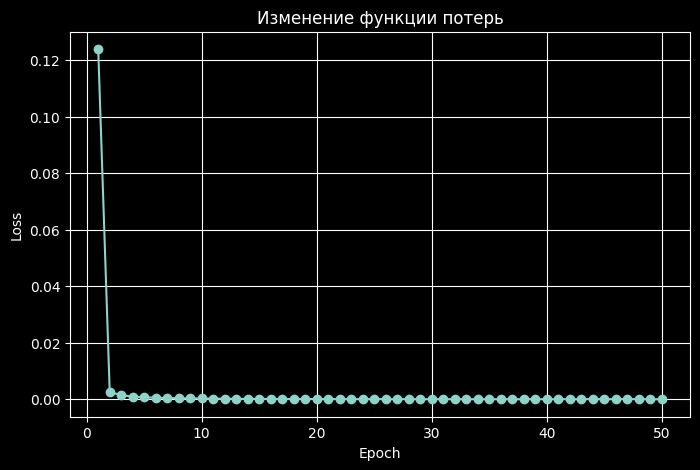

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), loss_history, marker='o')
plt.title('Изменение функции потерь')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

Дерево решений

In [23]:
def variance(y):
    mean = np.mean(y)
    return np.mean((y - mean) ** 2)


def best_split(X, y):

    best_feature = None
    best_threshold = None
    best_error = np.inf

    n_features = X.shape[1]

    for feature in range(n_features):

        feature_values = X[:, feature]

        values = np.sort(np.unique(feature_values))
        thresholds = (values[:-1] + values[1:]) / 2

        for threshold in thresholds:

            left_mask = feature_values <= threshold
            right_mask = feature_values > threshold

            if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                continue

            left_y = y[left_mask]
            right_y = y[right_mask]

            error = (
                len(left_y) * variance(left_y)
                + len(right_y) * variance(right_y)
            ) / len(y)

            if error < best_error:
                best_error = error
                best_feature = feature
                best_threshold = threshold

    return best_feature, best_threshold, best_error

In [24]:
class Node:

    def __init__(self,
                 feature=None,
                 threshold=None,
                 left=None,
                 right=None,
                 value=None):

        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

class MyDecisionTreeRegressor:
    def __init__(self, max_depth = 5, min_samples_split = 2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def fit(self, X, y):

        self.root = self.build_tree(X, y, depth=0)

    def build_tree(self, X, y, depth):

        if depth >= self.max_depth:
           return Node(value=np.mean(y))

        if len(y) < self.min_samples_split:
            return Node(value=np.mean(y))

        if len(np.unique(y)) == 1:
            return Node(value=np.mean(y))

        feature, threshold, error = best_split(X, y)

        left_mask = X[:, feature] <= threshold
        right_mask = X[:, feature] > threshold

        X_left = X[left_mask]
        X_right = X[right_mask]

        y_left = y[left_mask]
        y_right = y[right_mask]

        left_node = self.build_tree(X_left, y_left, depth + 1)
        right_node = self.build_tree(X_right, y_right, depth + 1)

        return Node(
           feature=feature,
           threshold=threshold,
           left=left_node,
           right=right_node
        )

    def predict_one(self, x):

        node = self.root

        while node.value is None:

            if x[node.feature] <= node.threshold:
                node = node.left
            else:
                node = node.right

        return node.value

    def predict(self, X):
        return np.array([self.predict_one(x) for x in X])

In [25]:
tree = MyDecisionTreeRegressor()
tree.fit(X_train_scaled, y_train)
y_pred = tree.predict(X_test_scaled)

In [26]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.08261217681481643
MSE : 0.015075436998694687
RMSE: 0.12278207116144721
R²  : 0.9843369991832319


Random forest

In [27]:
class MyRandomForestRegressor:

    def __init__(self, n_estimators, max_depth = 5, min_samples_split = 2):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split

        self.trees = []

    def fit(self, X, y):

        self.trees = []

        indices = np.random.permutation(len(X))
        parts = np.array_split(indices, self.n_estimators)

        for part in parts:

            X_sample = X[part]
            y_sample = y[part]

            tree = MyDecisionTreeRegressor(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split
            )

            tree.fit(X_sample, y_sample)

            self.trees.append(tree)

    def predict(self, X):

        predictions = []

        for tree in self.trees:
            predictions.append(tree.predict(X))

        predictions = np.array(predictions)

        return np.mean(predictions, axis=0)

In [33]:
rnd_forest = MyRandomForestRegressor(10)
rnd_forest.fit(X_train_scaled, y_train)
rnd_forest_pred = rnd_forest.predict(X_test_scaled)

In [34]:
mae = mean_absolute_error(y_test, rnd_forest_pred)
mse = mean_squared_error(y_test, rnd_forest_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, rnd_forest_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.05052352309154301
MSE : 0.00600988183212201
RMSE: 0.07752342763398694
R²  : 0.993755883557249


Градиентный бустинг

In [35]:
class MyGradientBoostingRegressor:

    def __init__(self,
                 n_estimators=50,
                 learning_rate=0.1,
                 max_depth=3,
                 min_samples_split=2):

        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split

        self.trees = []
        self.initial_prediction = None

    def fit(self, X, y):

        self.trees = []
        self.initial_prediction = np.mean(y)

        prediction = np.full(len(y), self.initial_prediction)
        residuals = y - prediction

        for i in range(self.n_estimators):

            tree = MyDecisionTreeRegressor(
               max_depth=self.max_depth,
               min_samples_split=self.min_samples_split
            )

            tree.fit(X, residuals)

            tree_prediction = tree.predict(X)

            prediction += self.learning_rate * tree_prediction

            residuals = y - prediction

            self.trees.append(tree)
    def predict(self, X):
        prediction = np.full(len(X), self.initial_prediction)

        for tree in self.trees:
            prediction += (self.learning_rate * tree.predict(X))

        return prediction

In [36]:
gb = MyGradientBoostingRegressor(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=3
)

gb.fit(X_train_scaled, y_train)

gb_pred = gb.predict(X_test_scaled)

In [37]:
mae = mean_absolute_error(y_test, gb_pred)
mse = mean_squared_error(y_test, gb_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, gb_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.023791123477392113
MSE : 0.0015185870964176582
RMSE: 0.03896905306031516
R²  : 0.9984222261063754
